# Extraction Analysis

Recovery (recall/precision vs. ground truth) and hallucination rate for a single extraction run.

In [2]:
import sys
from pathlib import Path
%load_ext autoreload
%autoreload 2

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / 'src'))
sys.path.insert(0, str(REPO_ROOT / 'experiments'))
sys.path.insert(0, str(REPO_ROOT))

import re
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from analysis.loaders import load_extraction, load_combined_judgements, load_ground_truth, cached_match
from scholarlm.utils.unit_conversion import apply_unit_conversion
from analysis.metrics import recovery_rate, hallucination_rate, per_paper_metrics
from analysis.plots import recovery_bar, probability_distribution
from experiments.run_extraction import load_dataset_config
import paths

# ── Publication style ──
mpl.rcParams.update({
    # Fonts
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "text.usetex": False,  # set True if you have a TeX install and want perfect font matching

    # Font sizes — figure text should be ≤ body text (10pt)
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "legend.title_fontsize": 9,

    # Axes/ticks
    "axes.linewidth": 0.6,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.size": 1.5,
    "ytick.minor.size": 1.5,

    # Lines
    "lines.linewidth": 1.2,
    "lines.markersize": 4,

    # Legend
    "legend.frameon": False,
    "legend.borderpad": 0.3,
    "legend.columnspacing": 1.0,
    "legend.handletextpad": 0.5,

    # Figure — save as PDF vector, not PNG
    "figure.dpi": 150,        # display
    "savefig.dpi": 300,       # raster fallback only
    "savefig.format": "pdf",
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,       # TrueType, editable/searchable — required by many venues
    "ps.fonttype": 42,
})

In [3]:
SUPERSCRIPT_MAP = str.maketrans("⁰¹²³⁴⁵⁶⁷⁸⁹⁻⁺", "0123456789-+")

def normalize_superscripts(s: str) -> str:
    return re.sub(r"[⁰¹²³⁴⁵⁶⁷⁸⁹⁻⁺]+", lambda m: m.group().translate(SUPERSCRIPT_MAP), s)

## Load data

In [44]:
# ── Config ────────────────────────────────────────────────────────────────────
DATASET = 'pond_ten'
MODEL = 'gemma-3-27b'
EXTRACTION_DATE = '2026_04_14'  # set to None to use most recent run

config = load_dataset_config(DATASET)

In [45]:
records = load_extraction(DATASET, MODEL, EXTRACTION_DATE)
extraction_df = pd.DataFrame(records)
extraction_df = apply_unit_conversion(extraction_df, {})
extraction_df.loc[extraction_df.attribute == 'ph', 'units'] = 'None'
print(f'{len(extraction_df)} extracted measurements')
extraction_df.head()

4519 extracted measurements


,title,author,year,paper_code,document_id,name,abbreviations,location,ecosystem,entity_id,...,value,units,page_number,table_number,row_index,column_index,source,context,measurement_id,converted_value
0,classification trees as a tool for predicting ...,peretyatko; anatoly; teissier; samuel; de back...,2011,classification_trees,0,ponds from the Brussels Capital Region,NaN,Brussels Capital Region (Belgium),pond,doc_0_entity_0,...,3,m,[1],[None],[None],[None],[text],"[dramatic increase in the frequency, magnitude...",0,3.0
1,classification trees as a tool for predicting ...,peretyatko; anatoly; teissier; samuel; de back...,2011,classification_trees,0,ponds from the Brussels Capital Region,NaN,Brussels Capital Region (Belgium),pond,doc_0_entity_0,...,1,m,[12],[None],[None],[None],[text],[Fig. 7 Examples of conditions favouring cyano...,1,1.0
2,environmental conditions and macrophytes of ka...,zelnik; igor; potisek; mateja; gaberscik; alenka,2012,environmental_conditions,1,Brije,NaN,"Karst region (SW Slovenia, NE Italy)",pond,doc_1_entity_0,...,7.2,None,[6],[None],[None],[None],[text],[Environmental Conditions and Macrophytes...\n...,2,7.2
3,environmental conditions and macrophytes of ka...,zelnik; igor; potisek; mateja; gaberscik; alenka,2012,environmental_conditions,1,Brije,NaN,"Karst region (SW Slovenia, NE Italy)",pond,doc_1_entity_0,...,6.7,None,[6],[None],[None],[None],[text],[Environmental Conditions and Macrophytes...\n...,3,6.7
4,environmental conditions and macrophytes of ka...,zelnik; igor; potisek; mateja; gaberscik; alenka,2012,environmental_conditions,1,Dutovlje,NaN,"Karst region (SW Slovenia, NE Italy)",pond,doc_1_entity_1,...,7.2,None,[6],[None],[None],[None],[text],[Environmental Conditions and Macrophytes...\n...,4,7.2


In [46]:
ground_truth_df = load_ground_truth(config)
print(f'{len(ground_truth_df)} ground truth measurements')
ground_truth_df.loc[ground_truth_df.attribute == 'ph', 'units'] = 'None'
ground_truth_df.head()

1301 ground truth measurements


,document_id,name,identifiers,location,ecosystem,date,additional_details,attribute,value,units
0,classification_trees,3fnt,NaN,belgium,pond,NaN,NaN,max_depth,0.4,m
1,classification_trees,bcmb,NaN,belgium,pond,NaN,NaN,max_depth,0.8,m
2,classification_trees,beml,NaN,belgium,pond,NaN,NaN,max_depth,1.0,m
3,classification_trees,blkd,NaN,belgium,pond,NaN,NaN,max_depth,1.4,m
4,classification_trees,botn,NaN,belgium,pond,NaN,NaN,max_depth,0.8,m


In [47]:
try:
    judgements = load_combined_judgements(DATASET, MODEL, EXTRACTION_DATE)
    judged_df = pd.DataFrame(judgements)
    print(f'{len(judged_df)} judged measurements')
except:
    judged_df = None
    print('Judgements not available.')

4519 judged measurements


## Recovery + Hallucination

In [48]:
# NOTE: Some of the output units for the Nfix dataset are mostly correct,
#      but need small cosmetic adjustments to be directly matched. We do this here:

SUPERSCRIPT_MAP = str.maketrans("⁰¹²³⁴⁵⁶⁷⁸⁹⁻⁺", "0123456789-+")
SUBSCRIPT_MAP   = str.maketrans("₀₁₂₃₄₅₆₇₈₉₋₊", "0123456789-+")
SCRIPT_MAP = {**SUPERSCRIPT_MAP, **SUBSCRIPT_MAP}

# LaTeX-style super/subscripts: ^{-1}, ^-1, _{-1}, _-1
LATEX_SCRIPT_RE = re.compile(r"[\^_]\{([^}]*)\}|[\^_]([+-]?\d+)")

# 'mol N' / 'g C' → 'mol-N' / 'g-C'
ELEMENT_DASH_RE = re.compile(r"(mol|g) (N|C)")

# 'day' → 'd', 'hr' → 'h' as standalone tokens (don't touch 'Friday' or 'hour')
TIME_UNIT_RE = re.compile(r"\bday\b|\bhr\b")
TIME_UNIT_SUB = {"day": "d", "hr": "h"}


def nfix_clean_unit(s: str) -> str:
    if not isinstance(s, str):
        return s
    s = s.translate(SCRIPT_MAP)
    s = LATEX_SCRIPT_RE.sub(lambda m: m.group(1) if m.group(1) is not None else m.group(2), s)
    s = ELEMENT_DASH_RE.sub(r"\1-\2", s)
    s = TIME_UNIT_RE.sub(lambda m: TIME_UNIT_SUB[m.group()], s)
    return s

In [49]:
if 'pond' in DATASET:
    STRICT_MATCHING = {'document_id': 'paper_code', 'attribute': 'attribute', 'value': 'converted_value', 'units': 'units'}
    FUZZY_MATCHING  = {'name': 'name', 'location': 'location', 'ecosystem': 'ecosystem'}
elif 'nfix' in DATASET:
    extraction_df['attribute'] = extraction_df['attribute'].map({'nfix_rate_areal': 'nfix_rate', 'nfix_rate_volumetric': 'nfix_rate', 'nfix_rate_mass': 'nfix_rate', 'nfix_rate': 'nfix_rate'})
    extraction_df["units"] = extraction_df["units"].apply(nfix_clean_unit)
    STRICT_MATCHING = {'document_id': 'document_id', 'attribute': 'attribute', 'value': 'converted_value', 'units': 'units'}
    FUZZY_MATCHING  = {"name": "name", "site_type": "site_type"}
else:
    raise ValueError("Dataset not recognized.")

cache_path = paths.extraction(DATASET, MODEL, EXTRACTION_DATE) / 'match_cache.pkl'

matching, edges, weights = cached_match(
    ground_truth_df, extraction_df,
    strict_matching=STRICT_MATCHING,
    fuzzy_matching=FUZZY_MATCHING,
    fuzzy_threshold=0.0,
    cache_path=cache_path,
)

In [50]:
matching

[(2, 329),
 (4, 320),
 (19, 324),
 (23, 1),
 (27, 331),
 (33, 322),
 (34, 321),
 (35, 323),
 (36, 330),
 (37, 325),
 (38, 326),
 (39, 327),
 (40, 328),
 (48, 717),
 (49, 721),
 (50, 716),
 (51, 706),
 (52, 720),
 (53, 719),
 (54, 718),
 (55, 715),
 (56, 732),
 (57, 723),
 (58, 733),
 (59, 707),
 (60, 727),
 (61, 726),
 (62, 1249),
 (63, 730),
 (64, 731),
 (65, 722),
 (66, 729),
 (67, 724),
 (68, 1744),
 (69, 708),
 (70, 709),
 (71, 710),
 (72, 711),
 (73, 712),
 (74, 713),
 (75, 714),
 (76, 1849),
 (77, 1855),
 (79, 1862),
 (80, 1865),
 (82, 1871),
 (83, 38),
 (84, 39),
 (85, 1829),
 (86, 1883),
 (87, 1889),
 (89, 1894),
 (104, 73),
 (123, 2392),
 (124, 2398),
 (125, 2404),
 (126, 2410),
 (127, 2416),
 (128, 2422),
 (129, 2428),
 (130, 2434),
 (131, 2440),
 (132, 2169),
 (133, 2452),
 (134, 2458),
 (135, 2464),
 (136, 2470),
 (137, 2476),
 (139, 2488),
 (140, 2494),
 (141, 2500),
 (142, 2506),
 (144, 4091),
 (145, 3959),
 (146, 4222),
 (147, 3968),
 (148, 3991),
 (149, 4243),
 (150, 40

In [27]:
# IF human annotated judgements are available,
# determine edge weight threshold which corresponds to the best agreement
agreements = []
fuzzy_thresholds = np.linspace(0,1,21)

if judged_df is not None:
    hidx = judged_df['judgement_human'].dropna().index
    jlabels = judged_df['judgement_combined'].to_numpy(dtype = bool)[hidx]
    hlabels = judged_df['judgement_human'].to_numpy(dtype = bool)[hidx]
    
    for f_threshold in fuzzy_thresholds:
        gt_edge_exists = np.zeros(len(ground_truth_df), dtype = bool)
        ex_edge_exists = np.zeros(len(extraction_df), dtype = bool)
        for i, (gt_idx, ex_idx) in enumerate(edges):
            if weights[i] > f_threshold:
                gt_edge_exists[gt_idx] = True
                ex_edge_exists[ex_idx] = True
                
        agreements.append(
            ((ex_edge_exists[hidx] | jlabels) == hlabels).sum() / len(hlabels)
        )

    fig, ax = plt.subplots(figsize=(5, 4), dpi=300)

    ax.plot(
        fuzzy_thresholds, 
        agreements,
        marker='o',
        linewidth=2.5,
        markersize=5,
        color='#2E86AB',
        markeredgewidth=1.5,
        markeredgecolor='#2E86AB',
    )
    
    ax.set_xlabel('Fuzzy Matching Threshold')
    ax.set_ylabel('Agreement')
    
    ax.set_ylim(0.75, 0.95)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
    #ax.legend(loc='best', framealpha=0.95)
    
    # Improve tick label formatting
    ax.set_xticks(np.linspace(0, 1, 11))
    #ax.set_yticks(np.linspace(0.5, 1.0, 11))
    ax.tick_params(axis='both')
    
    plt.tight_layout()
    plt.savefig(f'../figures/extraction/human_agreement_{DATASET}_{MODEL}_{EXTRACTION_DATE}.pdf', dpi=300, bbox_inches='tight')
    plt.show()

In [51]:
THRESHOLD = 1/3

recovery = recovery_rate(
    ground_truth_df = ground_truth_df,
    extraction_df = extraction_df,
    strict_matching = STRICT_MATCHING,
    fuzzy_matching = FUZZY_MATCHING,
    fuzzy_threshold = THRESHOLD,
    cache_path = cache_path,
)

if judged_df is not None:
    hallucination = hallucination_rate(
        extraction_df = extraction_df,
        ground_truth_df = ground_truth_df,
        judged_df = judged_df,
        strict_matching = STRICT_MATCHING,
        fuzzy_matching = FUZZY_MATCHING,
        fuzzy_threshold = THRESHOLD,
        cache_path = cache_path,
        label_col = "judgement_combined"
    )
else:
    hallucination = np.nan


print("Recovery: ", recovery)
print("Hallucination: ", hallucination)

Recovery:  0.7132974634896234
Hallucination:  0.3089179021907502


In [ ]:
paper_metrics_df = per_paper_metrics(
    extraction_df = extraction_df,
    ground_truth_df = ground_truth_df,
    judged_df = judged_df,
    strict_matching = STRICT_MATCHING,
    fuzzy_matching = FUZZY_MATCHING,
    fuzzy_threshold = THRESHOLD,
    cache_path = cache_path,
    paper_col = "document_id",
    label_col = "judgement_combined"
)
paper_metrics_df

## Model Comparison

In [ ]:
# ── Config ────────────────────────────────────────────────────────────────────
DATASET = 'pond'
MODELS = ['gemma-3-27b']  # Add more models here as needed
EXTRACTION_DATES = ['2026_04_19']  # Corresponding extraction dates for each model
THRESHOLD = 1/3

# Verify matching lengths
assert len(MODELS) == len(EXTRACTION_DATES), "MODELS and EXTRACTION_DATES must have the same length"

config = load_dataset_config(DATASET)
ground_truth_df = load_ground_truth(config)

# Define matching rules based on dataset
if 'pond' in DATASET:
    STRICT_MATCHING = {'document_id': 'document_id', 'attribute': 'attribute', 'value': 'converted_value'}
    FUZZY_MATCHING  = {'name': 'name', 'location': 'location', 'ecosystem': 'ecosystem'}
elif 'nfix' in DATASET:
    STRICT_MATCHING = {'document_id': 'document_id', 'attribute': 'attribute', 'value': 'converted_value'}
    FUZZY_MATCHING  = {"name": "name", "site_type": "site_type"}
else:
    raise ValueError("Dataset not recognized.")

# Compute metrics for each model
results = []

for model, extraction_date in zip(MODELS, EXTRACTION_DATES):
    print(f"\nProcessing {model} ({extraction_date})...")

    # Load extraction data
    records = load_extraction(DATASET, model, extraction_date)
    extraction_df = pd.DataFrame(records)
    extraction_df = apply_unit_conversion(extraction_df, config.unit_conversion_table)

    if 'nfix' in DATASET:
        extraction_df['attribute'] = extraction_df['attribute'].map({'nfix_rate_areal': 'nfix_rate', 'nfix_rate_volumetric': 'nfix_rate', 'nfix_rate_mass': 'nfix_rate', 'nfix_rate': 'nfix_rate'})

    # Get cache path
    cache_path = paths.extraction(DATASET, model, extraction_date) / 'match_cache.pkl'

    # Load judgements if available
    try:
        judgements = load_combined_judgements(DATASET, model, extraction_date)
        judged_df = pd.DataFrame(judgements)
    except:
        judged_df = None

    # Compute recovery and hallucination
    recovery = recovery_rate(
        extraction_df=extraction_df,
        ground_truth_df=ground_truth_df,
        strict_matching=STRICT_MATCHING,
        fuzzy_matching=FUZZY_MATCHING,
        fuzzy_threshold=THRESHOLD,
        cache_path=cache_path,
    )

    hallucination = hallucination_rate(
        extraction_df=extraction_df,
        ground_truth_df=ground_truth_df,
        judged_df=judged_df,
        strict_matching=STRICT_MATCHING,
        fuzzy_matching=FUZZY_MATCHING,
        fuzzy_threshold=THRESHOLD,
        cache_path=cache_path,
        label_col="judgement_combined"
    )

    results.append({
        'model': model,
        'extraction_date': extraction_date,
        'recovery': recovery,
        'hallucination': hallucination,
    })

    print(f"  Recovery: {recovery:.3f}, Hallucination: {hallucination:.3f}")

# Create results dataframe
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print(results_df)
print("="*60)

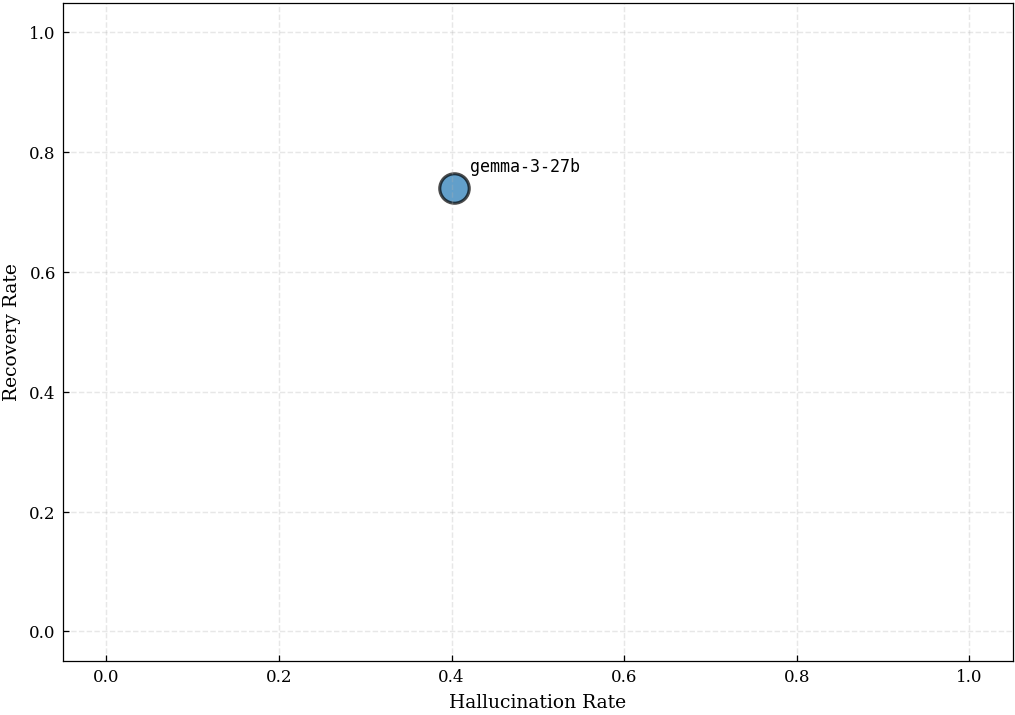

In [20]:
# Create scatter plot
fig, ax = plt.subplots(figsize=(7, 5))

# Use a colormap for distinct colors
cmap = plt.cm.tab10 if len(results_df) <= 10 else plt.cm.tab20
colors = [cmap(i) for i in range(len(results_df))]

# Plot points
scatter = ax.scatter(
    results_df['hallucination'],
    results_df['recovery'],
    s=200,
    c=colors,
    alpha=0.7,
    edgecolors='black',
    linewidth=1.5,
)

# Annotate with model names
for idx, row in results_df.iterrows():
    ax.annotate(
        row['model'],
        (row['hallucination'], row['recovery']),
        xytext=(8, 8),
        textcoords='offset points',
        fontsize=8,
        family='monospace',
    )

ax.set_xlabel('Hallucination Rate')
ax.set_ylabel('Recovery Rate')

ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig(f'../figures/extraction/model_comparison_{DATASET}.pdf', dpi=300, bbox_inches='tight')
plt.show()